In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s4e6/sample_submission.csv
/kaggle/input/playground-series-s4e6/train.csv
/kaggle/input/playground-series-s4e6/test.csv


In [2]:
train = pd.read_csv('/kaggle/input/playground-series-s4e6/train.csv')

In [3]:
test =  pd.read_csv('/kaggle/input/playground-series-s4e6/test.csv')

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76518 entries, 0 to 76517
Data columns (total 38 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   id                                              76518 non-null  int64  
 1   Marital status                                  76518 non-null  int64  
 2   Application mode                                76518 non-null  int64  
 3   Application order                               76518 non-null  int64  
 4   Course                                          76518 non-null  int64  
 5   Daytime/evening attendance                      76518 non-null  int64  
 6   Previous qualification                          76518 non-null  int64  
 7   Previous qualification (grade)                  76518 non-null  float64
 8   Nacionality                                     76518 non-null  int64  
 9   Mother's qualification                 

In [5]:
# Check for Nan values in data
train.isna().sum()

id                                                0
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship 

In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51012 entries, 0 to 51011
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   id                                              51012 non-null  int64  
 1   Marital status                                  51012 non-null  int64  
 2   Application mode                                51012 non-null  int64  
 3   Application order                               51012 non-null  int64  
 4   Course                                          51012 non-null  int64  
 5   Daytime/evening attendance                      51012 non-null  int64  
 6   Previous qualification                          51012 non-null  int64  
 7   Previous qualification (grade)                  51012 non-null  float64
 8   Nacionality                                     51012 non-null  int64  
 9   Mother's qualification                 

In [7]:
# Check for Nan Values
test.isna().sum()

id                                                0
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship 

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

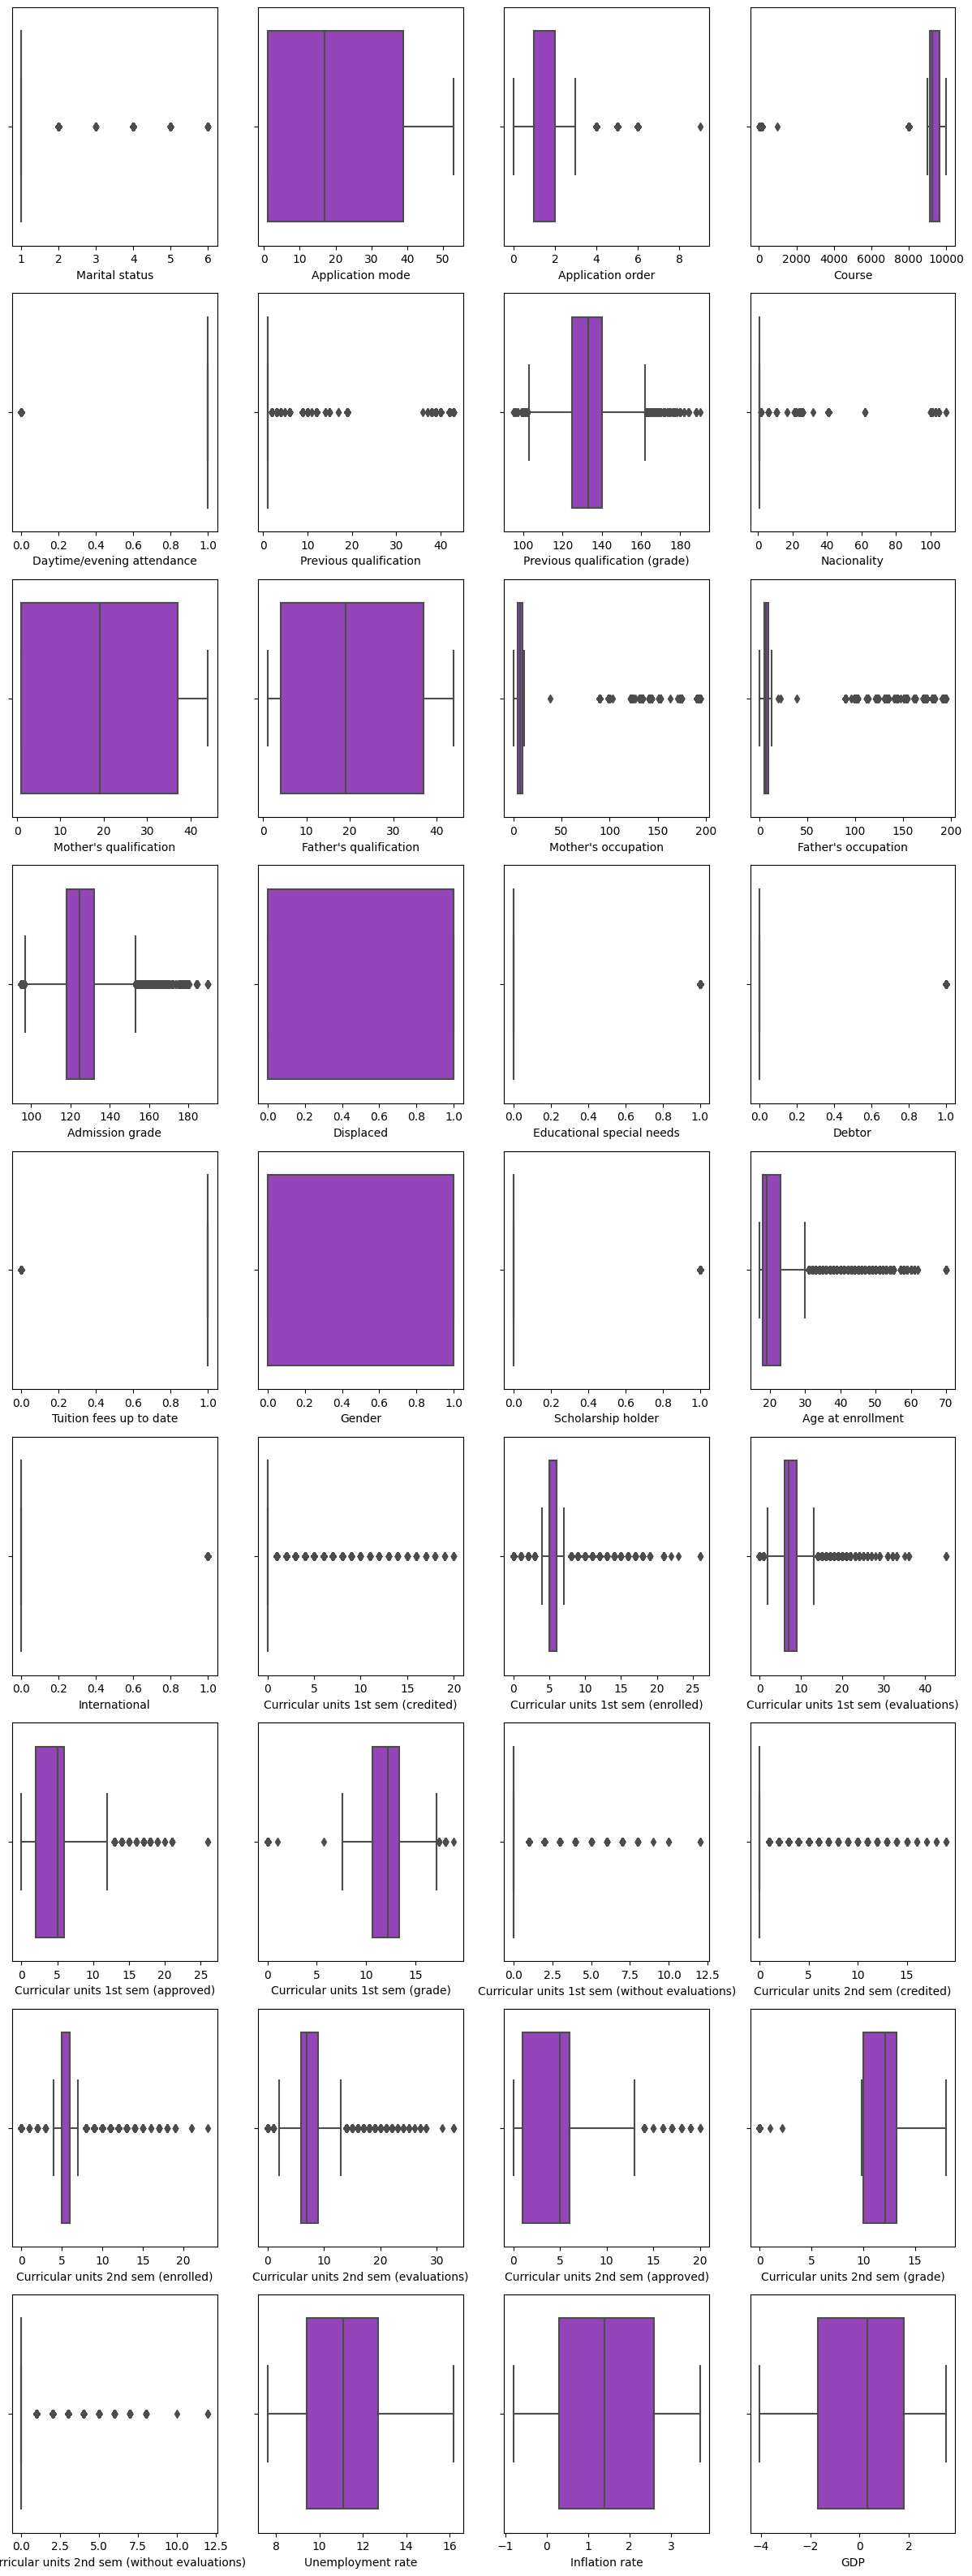

In [9]:
# Store Independent Features in a separate var for ease 
colm = list((train.select_dtypes(include = ['int','float'])).columns)
colm.remove('id')
plt.figure(figsize = (15,45))
for i, col in enumerate(colm,1):
    plt.subplot(10,4,i)
    sns.boxplot(data  = train, x = train[col], color = 'darkorchid')



# Data Preprocessing

In [10]:
train['Target'].unique()

array(['Graduate', 'Dropout', 'Enrolled'], dtype=object)

In [11]:
train['Target'] = train['Target'].map({'Graduate':2, 'Enrolled' : 1, 'Dropout':0},)

# Selecting The Model Based On Performance

In [12]:
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV

In [13]:
x_train, x_test, y_train, y_test = train_test_split(train[colm], train['Target'], test_size = 0.2, random_state = 42)

In [14]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score , accuracy_score, recall_score, roc_auc_score, precision_score

In [15]:
models = {
    'RandomForest' : RandomForestClassifier(),
    'XGB' : XGBClassifier(),
    'LightBoost' : LGBMClassifier(),
    'GradientBooster' : GradientBoostingClassifier(),
    'CatBooster' : CatBoostClassifier(verbose = 0)
}

In [16]:
for model in models:
    
    clf = models[model]
    clf.fit(x_train, y_train)
    y_train_pred = clf.predict(x_train)
    y_pred = clf.predict(x_test)
    train_prob = clf.predict_proba(x_train)
    test_prob = clf.predict_proba(x_test)
    
    
    train_accuracy = accuracy_score(y_train,y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred, average = 'weighted')
    train_recall = recall_score(y_train, y_train_pred,average = 'weighted')
    train_auc = roc_auc_score(y_train,train_prob, multi_class = 'ovr')
    train_precision = precision_score(y_train, y_train_pred,average = 'weighted')
    
    test_accuracy = accuracy_score(y_test,y_pred)
    test_f1 = f1_score(y_test, y_pred, average = 'weighted')
    test_recall = recall_score(y_test, y_pred,average = 'weighted')
    test_auc = roc_auc_score(y_test,test_prob, multi_class = 'ovr')
    test_precision = precision_score(y_test, y_pred,average = 'weighted')
    
    print('-' * 40)
    print(f'<--- Test Predcition Scoring For {model} ---> ')
    print(f'-Test Accuracy = {test_accuracy}')
    print(f'-Test Recall = {test_recall}')
    print(f'-Test Precision = {test_precision}')
    print(f'-Test F1 Score = {test_f1}')
    print(f'-Test ROC auc Score = {test_auc}')
    print('\n')
    print(f'<--- Train Predcition Scoring For {model} ---> ')
    print(f'-Accuracy = {train_accuracy}')
    print(f'-Recall = {train_recall}')
    print(f'-Test Precision = {train_precision}')
    print(f'-F1 Score = {train_f1}')
    print(f'ROC auc Score = {train_auc}')
    
    print('-' * 40)
    

----------------------------------------
<--- Test Predcition Scoring For RandomForest ---> 
-Test Accuracy = 0.8257318348144276
-Test Recall = 0.8257318348144276
-Test Precision = 0.8238149802331329
-Test F1 Score = 0.8233286138283643
-Test ROC auc Score = 0.9289868892066665


<--- Train Predcition Scoring For RandomForest ---> 
-Accuracy = 1.0
-Recall = 1.0
-Test Precision = 1.0
-F1 Score = 1.0
ROC auc Score = 1.0
----------------------------------------
----------------------------------------
<--- Test Predcition Scoring For XGB ---> 
-Test Accuracy = 0.8331808677469943
-Test Recall = 0.8331808677469943
-Test Precision = 0.830763052562188
-Test F1 Score = 0.8308953794655102
-Test ROC auc Score = 0.936404292188134


<--- Train Predcition Scoring For XGB ---> 
-Accuracy = 0.8812689907537491
-Recall = 0.8812689907537491
-Test Precision = 0.881222749219193
-F1 Score = 0.880323120244485
ROC auc Score = 0.9684303142236667
----------------------------------------
[LightGBM] [Warning] Foun

> I am going with lightboost because it is not overfitting that much and they give better results

# HyperParameter Tuning For XGboost

In [17]:
import warnings
warnings.simplefilter('ignore')

In [18]:
import optuna

In [19]:
# def objective(trial):
#     # Define hyperparameter search space
#     param = {
#         'tree_method': 'gpu_hist',  # Use 'hist' if GPU is not available
#         'lambda': trial.suggest_loguniform('lambda', 1e-8, 1.0),
#         'alpha': trial.suggest_loguniform('alpha', 1e-8, 1.0),
#         'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.4, 1.0),
#         'subsample': trial.suggest_uniform('subsample', 0.4, 1.0),
#         'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#         'max_depth': trial.suggest_int('max_depth', 3, 9),
#         'random_state': 42,
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
#     }

#     # Train model
#     model = XGBClassifier(**param)
#     model.fit(x_train, y_train)

#     # Make predictions
#     preds = model.predict(x_test)
#     accuracy = accuracy_score(y_test, preds)

#     return accuracy

# # Create study and optimize the objective function
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=40)

In [20]:
# study.best_params

In [21]:
xgb = XGBClassifier(reg_lambda = 0.2475, alpha = 2.4299, colsample_bytree = 0.651, subsample = 0.5494, learning_rate = 0.0444, n_estimators = 967, max_depth =6, min_child_weight = 7 )

In [22]:
xgb.fit(x_train,y_train)

XGBClassifier(alpha=2.4299, base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.651, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.0444, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=7, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=967, n_jobs=None,
              num_parallel_tree=None, ...)

In [23]:
y_xgb = xgb.predict(x_test)
print(accuracy_score(y_test, y_xgb))

0.8355985363303712


# Hyperparameter Tuning For LightBoost With HyperOpt

In [24]:
from hyperopt import hp, fmin, space_eval, STATUS_OK, tpe, Trials

In [25]:
light_params = {
    'lambda_l1': hp.quniform('lambda_l1',1,1000,1),
    'lambda_l2': hp.quniform('lambda_l2',1,1000,1),
    'max_depth' : hp.quniform('max_depth', 1, 15, 1 ),
    'feature_fraction' : hp.uniform('feature_fraction', 0.5,1),
    'learning_rate' : hp.uniform('learning_rate', 0.001, 1),
    'min_data_in_leaf' : hp.quniform('min_data_in_leaf',1,12,1),
    'n_estimators' : hp.quniform('n_estimators' , 100,1200,100),
    'verbose' : -1
}

In [26]:
# def light_objective(space):
#     clf = LGBMClassifier(
#         lambda_l1 = int(space['lambda_l1']),
#         lambda_l2 = int(space['lambda_l2']),
#         feature_fraction = np.round(space['feature_fraction'],2),
#         learning_rate = float(space['learning_rate']),
#         min_data_in_leaf = int(space['min_data_in_leaf']),
#         n_estimators = int(space['n_estimators']),
#         max_depth = int(space['max_depth']),
#         verbose = -1
#     )
#     score = cross_val_score(clf,x_train,y_train, cv = 3, scoring = 'accuracy').mean()
#     return({'loss':-score, 'status':STATUS_OK})
    
# light_trials = Trials()
# best_light = fmin(
#         space = light_params,
#         fn = light_objective,
#         trials = light_trials,
#         max_evals = 100,
#         algo = tpe.suggest
#     )

In [27]:
#  (space_eval(light_params, best_light))

In [28]:
lgbm = LGBMClassifier(feature_fraction = 0.70, lambda_l1 = 14, lambda_l2 = 1, verbose = -1, max_depth = 12, min_data_in_leaf =2, n_estimators = 500, learning_rate = 0.03572)

In [29]:
lgbm.fit(x_train, y_train)
y_pred_light = lgbm.predict(x_test)

In [30]:
print(accuracy_score(y_test, y_pred_light))

0.8347490852064819


In [31]:
y_pred_test = xgb.predict(test[colm])

# Result Submission

In [32]:
result = pd.DataFrame(index = test['id'],data = y_pred_test, columns = ['Target'])

In [33]:
result['Target'] = result['Target'].map({0:'Dropout',1:'Enrolled',2:'Graduate'})

In [34]:
result

,Target
id,
76518,Dropout
76519,Graduate
76520,Graduate
76521,Graduate
76522,Enrolled
...,...
127525,Dropout
127526,Dropout
127527,Dropout


In [35]:
result.to_csv('submission.csv')